# Pre-Processing Aided Divide and Conquer for Brain Tumor Segmentation: 
## The Case of Enhancing Tumor Using 3D U-Net

---

### Abstract

Glioblastoma is the most aggressive form of primary brain tumour; accurate
delineation of its **Enhancing Tumor (ET)** sub-region from multi-modal MRI is
critical for surgical planning, treatment-response monitoring, and survival
prediction.  This thesis proposes a **pre-processing-aided divide-and-conquer**
formulation: the segmentation problem is *divided* into the three nested
clinical sub-regions of BraTS (Whole Tumour, Tumour Core, Enhancing Tumour)
and *conquered* jointly by a single 3D U-Net with three independent sigmoid
output heads sharing one encoder–decoder trunk.  A reusable preprocessing
module supplies the model with intensity-standardised, contrast-enhanced
inputs and a family of physics-motivated **enhancement-tumour-specific feature channels**
(enhancement maps, edge detectors, ring detectors).  Two orthogonal ablation
axes — per-region loss weighting and preprocessing technique — are evaluated
under matched conditions on the BraTS 2020 dataset.

---

### BraTS sub-region hierarchy

The three target regions are *nested anatomical sets*, not disjoint classes:

| sub-region | symbol | composition (BraTS labels) | typical volume share |
|------------|--------|----------------------------|----------------------|
| Whole Tumour      | **WT** | edema  ∪  necrosis  ∪  enhancing  (labels 1, 2, 4) | 5–10 %  of brain |
| Tumour Core       | **TC** | necrosis  ∪  enhancing  (labels 1, 4)              | 1–3 %   of brain |
| Enhancing Tumour  | **ET** | enhancing only  (label 4)                          | 0.3–1 % of brain |

Containment: **WT ⊇ TC ⊇ ET**.  The proposed network outputs three
*independent* sigmoid maps for these regions; the natural containment
emerges from co-trained shared features rather than being enforced by
a softmax constraint.

---

### Pipeline overview

```
   ┌──────────────────────────────────────────────────────────────────────┐
   │  Patient volume  (240 × 240 × 155, 4 modalities: T1, T1ce, T2, FLAIR) │
   └─────────────────────────────┬────────────────────────────────────────┘
                                 │
                                 ▼
       ┌────────── Preprocessing  (preprocessing.py module) ──────────┐
       │  Always: percentile-clip [0.5, 99.5]  +  per-modality z-score │
       │  Optional (ablatable):  N4 bias correction                    │
       │                         Nyúl–Udupa histogram standardisation │
       │                         CLAHE on T1ce / FLAIR                 │
       │  Optional (extra channels): enhancement map, normalised enh., │
       │                              Sobel | T1ce, LoG of enhancement │
       └─────────────────────────────────┬────────────────────────────┘
                                         │
                                         ▼
                Random patch sampling   (96³ on 6 GB GPU)
                tumour-centric  (RandCropByPosNegLabeld, pos = 1, neg = 0)
                                         │
                                         ▼
       ┌──────────────────────────────────────────────────────────────────┐
       │             Shared 3D U-Net encoder–decoder                     │
       │   channels (16, 32, 64, 128, 160) · GroupNorm · num_res_units = 2 │
       └────────────────────┬───────────────┬───────────────┬──────────────┘
                            │               │               │
                            ▼               ▼               ▼
                       WT head          TC head         ET head
                       (sigmoid)        (sigmoid)       (sigmoid)        ← 3 binary maps, same spatial size
                            │               │               │
                            └─── joint Dice + BCE loss with per-region weights ───┘
                                         │
                                         ▼
                  Sliding-window inference  →  per-region test Dice
                  (96³ window, 50 % overlap, Gaussian weighting)
```

---

### Dataset

| split        | patient volumes | percent |
|--------------|-----------------|---------|
| Train        | **221**         | 60 %    |
| Validation   | **73**          | 20 %    |
| Test         | **75**          | 20 %    |
| **Total**    | **369**         | 100 %   |

- BraTS 2020 (UPenn), four co-registered, skull-stripped modalities
  (T1, T1ce, T2, FLAIR), 240 × 240 × 155 volumes, ≈ 155 axial slices each.
- **Volume-level split** at fixed seed (42): a patient's slices appear in
  *exactly one* of train / val / test — no spatial leakage between splits.
- 57,195 axial slice files in total, aggregated into 3D volumes on the fly.

---

### Two-axis experimental design

The thesis evaluates contributions along two **orthogonal** axes; the
winning configuration on the first axis is fixed, then the second axis
is swept:

| axis | ablation | values evaluated |
|------|----------|------------------|
| 1. Per-region loss weighting | divide-and-conquer balance | equal, ET-heavy, WT-anchored, ET-only |
| 2. Preprocessing technique   | thesis preprocessing contribution | baseline, +N4, +Nyúl, +CLAHE, +enh. channels, full |

This design avoids a 4 × 6 grid (24 runs) while still measuring each axis
under conditions favourable to the other — a principled trade-off between
combinatorial coverage and training-time budget.

---

### Reproducibility

- Random seed: **42** (Python `random`, NumPy, PyTorch, CUDA, MONAI).
- Patch sampler `RandCropByPosNegLabeld` re-seeded at the start of every
  ablation row so all rows see *identical* random crops; differences
  between rows reflect only the configuration change, not RNG drift.
- Resume-aware training: full model + optimiser + scheduler + history
  state are saved to `singlestage3d_last.pth` every epoch.
- Per-row best checkpoints are saved under tagged filenames
  (`singlestage3d_best__weighting_<scheme>.pth`,
  `singlestage3d_best__<preproc_row>.pth`) so no row can overwrite
  another's results.

---

### Hardware constraints (limitations declared up-front)

This thesis is implemented on a single consumer GPU with **6 GB VRAM**.
Patch size is therefore set to **96³** (vs the conventional 128³ used by
competitive BraTS submissions) and the U-Net channel widths to
**(16, 32, 64, 128, 160)**.  Quantitative limitations imposed by this
choice are discussed in the Discussion chapter; no qualitative
preprocessing or architectural decision is gated by GPU memory.

---

### Installation

```bash
pip install monai SimpleITK nibabel torch torchvision
```

`SimpleITK` is required only for N4 bias correction (ablation row 2);
all other code paths run without it.


In [1]:
# Windows/Anaconda OpenMP duplicate-runtime workaround (harmless).
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
# 6GB GPU: enable expandable memory segments to reduce fragmentation OOMs
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys, re, time, math, glob, json, warnings
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple, Optional, Dict

import numpy as np
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from monai.networks.nets import SegResNet, UNet as MonaiUNet
    from monai.losses import DiceCELoss
    from monai.inferers import sliding_window_inference
    from monai.transforms import (
        Compose, RandCropByPosNegLabeld, RandFlipd, RandScaleIntensityd,
        RandShiftIntensityd, EnsureTyped,
    )
    from monai.data import list_data_collate
    _HAS_MONAI = True
except ImportError:
    _HAS_MONAI = False
    warnings.warn('MONAI not installed. Run `pip install monai`.')

sys.path.insert(0, os.path.abspath('.'))
import preprocessing as pp

print('preprocessing.py loaded from', pp.__file__)
print('MONAI available:', _HAS_MONAI)


preprocessing.py loaded from c:\Users\bhmed\Desktop\GUC\Bachelor\BrainTumorSegmentation-2D-Unet-PyTorch\preprocessing.py
MONAI available: True


In [2]:
CFG = {
    'data_dir':  'BraTS2020_training_data/content/data',
    'cache_dir': './cache_3d_singlestage',
    'checkpoint_dir': './checkpoints',
    'seed': 42,

    # ---- Preprocessing flags (thesis ablation switches) ----
    'use_n4':                  False,   # SimpleITK required; very slow
    'use_nyul':                False,   # fits on training set
    'use_clahe_t1ce':          False,
    'use_clahe_flair':         False,
    'use_enhancement_channels': False,  # adds 4 extra channels (enh, norm-enh, sobel, LoG)

    # ---- Patch / dataloader ----
    'patch_size': (96, 96, 96),    # reduced from 128^3 for 6GB GPUs
    'pos_ratio':  1.0,          # RandCropByPosNegLabeld: 1 patch centred on tumour ...
    'neg_ratio':  0.0,          # all patches tumour-centric (avoids InstanceNorm NaN on empty bg patches)
    'samples_per_volume': 2,    # with bs=1, effective batch = 2
    'batch_size': 1,            # 6GB GPU -> bs=1; effective=2 via samples_per_volume
    'num_workers': 0,

    # ---- Model ----
    'model': 'unet',                # switched from segresnet to plain 3D U-Net (thesis title alignment)
    'segresnet_init_filters': 8,   # reduced from 16 for 6GB GPUs
    'segresnet_dropout': 0.2,
    'unet_channels': (16, 32, 64, 128, 160),  # shrunk from (32..320) for 6GB GPU
    'unet_strides':  (2, 2, 2, 2),

    # ---- Optimisation ----
    'epochs':  80,
    'lr':      1e-4,
    'weight_decay': 1e-5,
    'warmup_epochs': 2,
    'grad_clip': 1.0,
    'early_stop_patience': 15,
    'val_every': 2,

    # ---- Loss ----
    'dice_weight': 1.0,
    'ce_weight':   1.0,
    # (WT, TC, ET) task weights - auto-normalised inside WeightedDiceCE
    # Thesis reports these as percentages (e.g. 0.33/0.33/0.33 for Equal)
    'task_weights': (1.0, 1.0, 1.0),

    # ---- Inference ----
    'sw_roi':     (96, 96, 96),   # match patch_size
    'sw_overlap': 0.5,
    'sw_gaussian': True,
    'et_threshold': 0.5,

    # ---- Runtime ----
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

os.makedirs(CFG['cache_dir'],      exist_ok=True)
os.makedirs(CFG['checkpoint_dir'], exist_ok=True)
print('Device:', CFG['device'])


Device: cuda


In [3]:
def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(CFG['seed'])

DATA_DIR = CFG['data_dir']

def get_volume_id(fname: str) -> str:
    return os.path.basename(fname).split('_slice_')[0]

def slice_index(fname: str) -> int:
    m = re.search(r'_slice_(\d+)', fname)
    return int(m.group(1)) if m else -1

def split_by_volume(file_list, seed=42, ratios=(0.6, 0.2, 0.2)):
    import random as _random
    rng = _random.Random(seed)
    volume_ids = sorted(set(get_volume_id(f) for f in file_list))
    rng.shuffle(volume_ids)
    n = len(volume_ids); n_tr = int(ratios[0] * n); n_vl = int(ratios[1] * n)
    return (set(volume_ids[:n_tr]),
            set(volume_ids[n_tr:n_tr + n_vl]),
            set(volume_ids[n_tr + n_vl:]))

h5_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.h5')])
train_vols, val_vols, test_vols = split_by_volume(h5_files, seed=42)
print(f'{len(h5_files)} slice files, {len(train_vols) + len(val_vols) + len(test_vols)} volumes')
print(f'Train: {len(train_vols)}  Val: {len(val_vols)}  Test: {len(test_vols)}')


57195 slice files, 369 volumes
Train: 221  Val: 73  Test: 75


In [4]:
def group_slices_by_volume(file_list):
    groups = defaultdict(list)
    for f in file_list:
        groups[get_volume_id(f)].append(f)
    for vid in groups:
        groups[vid].sort(key=slice_index)
    return dict(groups)

volume_slices = group_slices_by_volume(h5_files)
example_vid = next(iter(volume_slices))
print(f'Example volume: {example_vid}  n_slices={len(volume_slices[example_vid])}')


Example volume: volume_100  n_slices=155


## Preprocessing pipeline

### Application order

```
   raw 4-modality volume
            │
            ▼
   ┌───────────────────────┐
   │ N4 bias correction    │   ← if use_n4=True (per modality, ~15 s/vol)
   └──────────┬────────────┘
              ▼
   ┌───────────────────────┐
   │ Nyúl landmark mapping │   ← if use_nyul=True (per modality)
   └──────────┬────────────┘
              ▼
   ┌───────────────────────┐
   │ CLAHE on T1ce / FLAIR │   ← if use_clahe_*=True (per slice)
   └──────────┬────────────┘
              ▼
   ┌───────────────────────┐
   │ Percentile-clip + z-score (always on, baseline)
   └──────────┬────────────┘
              ▼
   ┌───────────────────────┐
   │ Optional 4 ET-feature channels (enh, normEnh, Sobel, LoG)
   │   ← if use_enhancement_channels=True (built at __getitem__ time, not cached)
   └──────────┬────────────┘
              ▼
   model input  (B, 4 or 8, D, H, W)
```

This ordering is deliberate.  N4 corrects multiplicative drift first
(any later step would otherwise inherit the drift).  Nyúl maps each
volume's intensity histogram onto a fixed reference set, then CLAHE
locally enhances tumour-boundary contrast on T1ce/FLAIR.  Z-score
runs **last** so its mean/variance statistics are computed on the
fully-processed signal, not on the raw drift-contaminated values.

### Always-applied baseline

| step | implementation | purpose |
|------|----------------|---------|
| Percentile clipping `[0.5 %, 99.5 %]` | `pp.percentile_clip_zscore` | Removes intensity outliers (gadolinium hot-spots, motion artefacts) |
| Per-modality z-score within brain mask | `pp.percentile_clip_zscore` | Zero-mean / unit-variance per modality, computed on brain voxels only |
| Random spatial flip + intensity shift/scale | MONAI `RandFlipd`, `RandScaleIntensityd`, `RandShiftIntensityd` | Standard training-time augmentation |

### Optional, ablation-toggleable steps

| CFG flag | function (`preprocessing.py`) | role |
|----------|------------------------------|------|
| `use_n4`                 | `pp.n4_bias_correction`         | Corrects scanner intensity drift across the volume |
| `use_nyul`               | `pp.fit_nyul_landmarks` + `pp.apply_nyul_standardization` | Canonicalises per-modality intensity histograms across patients |
| `use_clahe_t1ce`         | `pp.apply_clahe` on T1ce        | Local contrast enhancement on the post-contrast image (sharpens ET ring) |
| `use_clahe_flair`        | `pp.apply_clahe` on FLAIR       | Local contrast enhancement on FLAIR (sharpens edema boundary, helps WT)  |
| `use_enhancement_channels` | builds 4 extra channels (`enhancement_map_alpha`, `normalized_enhancement`, `sobel_magnitude`, `laplacian_of_gaussian`) | Physics- and edge-motivated ET-specific feature inputs |

In [5]:
def load_raw_volume(vid: str, slice_files: List[str]):
    imgs, masks = [], []
    for fname in slice_files:
        with h5py.File(os.path.join(DATA_DIR, fname), 'r') as f:
            img = f['image'][:]              # (H, W, 4)
            msk = f['mask'][:]               # (H, W, 3) or (H, W)
        imgs.append(img.astype(np.float32))
        if msk.ndim == 3:
            lbl = np.zeros(msk.shape[:2], dtype=np.uint8)
            lbl[msk[..., 0] > 0] = 1
            lbl[msk[..., 1] > 0] = 2
            lbl[msk[..., 2] > 0] = 4
        else:
            lbl = msk.astype(np.uint8)
        masks.append(lbl)
    return np.stack(imgs, axis=0), np.stack(masks, axis=0)


def _prep_config_hash() -> str:
    return '_'.join([
        f'n4{int(CFG["use_n4"])}',
        f'ny{int(CFG["use_nyul"])}',
        f'cT{int(CFG["use_clahe_t1ce"])}',
        f'cF{int(CFG["use_clahe_flair"])}',
    ])


def _cache_subdir() -> str:
    return os.path.join(CFG['cache_dir'], _prep_config_hash())


def preprocess_volume(img_dhwc: np.ndarray, nyul_ref: Optional[dict] = None) -> np.ndarray:
    out = img_dhwc.astype(np.float32).copy()
    brain = (np.abs(out).sum(axis=-1) > 0).astype(np.uint8)

    # 1) N4 bias correction (optional)
    if CFG['use_n4'] and pp._HAS_SITK:
        for c in range(out.shape[-1]):
            try:
                out[..., c] = pp.n4_bias_correction(out[..., c], brain_mask=brain)
            except Exception as e:
                warnings.warn(f'N4 failed on channel {c}: {e}')

    # 2) Nyul-Udupa histogram standardisation (optional)
    if CFG['use_nyul'] and nyul_ref is not None:
        for c in range(out.shape[-1]):
            if c in nyul_ref:
                out[..., c] = pp.apply_nyul_standardization(out[..., c], brain, nyul_ref[c])

    # 3) CLAHE per-slice on T1ce (ch 1) and FLAIR (ch 3)
    if CFG['use_clahe_t1ce']:
        for d in range(out.shape[0]):
            out[d, :, :, 1] = pp.apply_clahe(out[d, :, :, 1])
    if CFG['use_clahe_flair']:
        for d in range(out.shape[0]):
            out[d, :, :, 3] = pp.apply_clahe(out[d, :, :, 3])

    # 4) Baseline z-score per modality (always on)
    for c in range(out.shape[-1]):
        out[..., c] = pp.percentile_clip_zscore(out[..., c], brain, pct_clip=(0.5, 99.5))

    return out


def fit_nyul_on_training(vids, sample_size=50) -> dict:
    per_c = {c: ([], []) for c in range(4)}
    for vid in tqdm(list(vids)[:sample_size], desc='Nyul fit'):
        img, _ = load_raw_volume(vid, volume_slices[vid])
        brain = (np.abs(img).sum(axis=-1) > 0).astype(np.uint8)
        for c in range(4):
            per_c[c][0].append(img[..., c])
            per_c[c][1].append(brain)
    return {c: pp.fit_nyul_landmarks(v, m) for c, (v, m) in per_c.items()}


def cache_all_volumes(volume_ids):
    sd = _cache_subdir(); os.makedirs(sd, exist_ok=True)
    nyul_ref = None
    if CFG['use_nyul']:
        ny_path = os.path.join(sd, 'nyul_ref.npz')
        if os.path.exists(ny_path):
            _d = np.load(ny_path)
            nyul_ref = {int(k): _d[k] for k in _d.files}
            print('Loaded cached Nyul reference.')
        else:
            nyul_ref = fit_nyul_on_training(train_vols)
            np.savez(ny_path, **{str(k): v for k, v in nyul_ref.items()})

    for vid in tqdm(list(volume_ids), desc=f'Preprocess [{_prep_config_hash()}]'):
        out_path = os.path.join(sd, f'{vid}.npz')
        if os.path.exists(out_path):
            continue
        img_raw, mask_lbl = load_raw_volume(vid, volume_slices[vid])
        img_pp = preprocess_volume(img_raw, nyul_ref=nyul_ref)
        np.savez_compressed(out_path,
                             image=img_pp.astype(np.float16),
                             mask=mask_lbl.astype(np.uint8))


def load_cached_volume(vid: str) -> Tuple[np.ndarray, np.ndarray]:
    d = np.load(os.path.join(_cache_subdir(), f'{vid}.npz'))
    return d['image'].astype(np.float32), d['mask']


# ---- Run preprocessing (baseline = z-score only, first run) ----
all_vids = sorted(train_vols | val_vols | test_vols)
cache_all_volumes(all_vids)
print(f'Cache ready at {_cache_subdir()}')


Preprocess [n40_ny0_cT0_cF0]:   0%|          | 0/369 [00:00<?, ?it/s]

Cache ready at ./cache_3d_singlestage\n40_ny0_cT0_cF0


## Visualise a raw example volume

Sanity check on the h5 loader: shows the four MRI modalities (T1, T1ce, T2, FLAIR)
and the ground-truth label overlay (NCR = red, ED = green, ET = yellow) for a few
slices of one training volume, *before* any preprocessing.


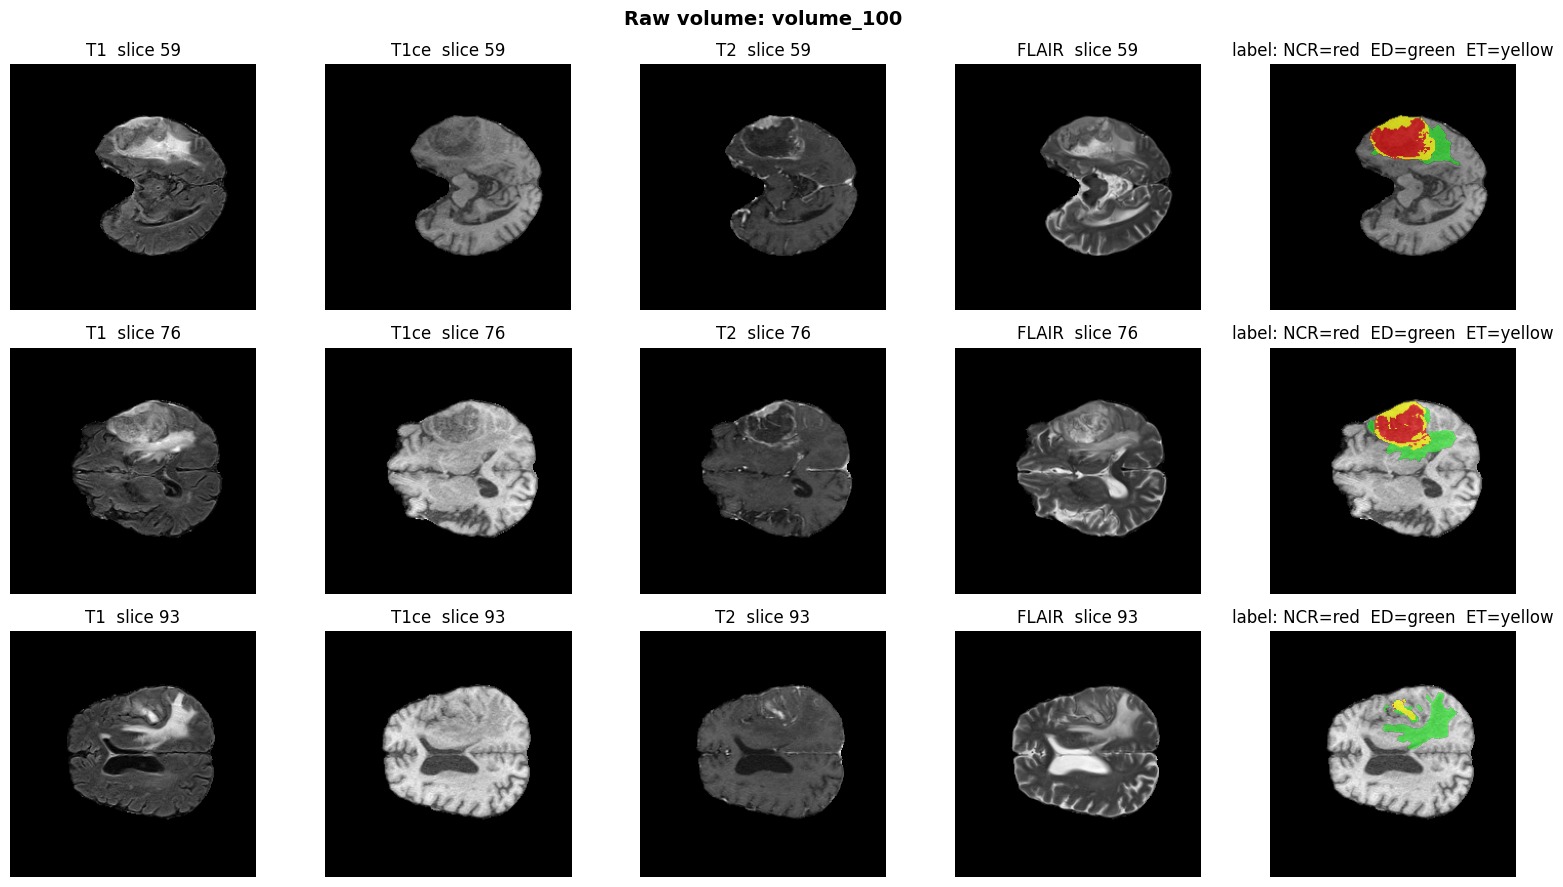

In [6]:
def show_raw_volume(vid, n_slices=3):
    img_raw, mask_raw = load_raw_volume(vid, volume_slices[vid])
    tumor_z = [z for z in range(mask_raw.shape[0]) if (mask_raw[z] > 0).any()]
    if tumor_z:
        step = max(1, len(tumor_z) // (n_slices + 1))
        sel = tumor_z[step::step][:n_slices]
    else:
        sel = [img_raw.shape[0] // 2]
    mods = ["T1", "T1ce", "T2", "FLAIR"]
    fig, axes = plt.subplots(len(sel), 5, figsize=(16, 3 * len(sel)),
                              squeeze=False)
    for row, z in enumerate(sel):
        for c in range(4):
            axes[row, c].imshow(img_raw[z, :, :, c], cmap="gray")
            axes[row, c].set_title(f"{mods[c]}  slice {z}")
            axes[row, c].axis("off")
        axes[row, 4].imshow(img_raw[z, :, :, 1], cmap="gray")
        m = mask_raw[z]
        overlay = np.zeros((*m.shape, 4))
        overlay[m == 1] = [1, 0, 0, 0.6]   # NCR red
        overlay[m == 2] = [0, 1, 0, 0.5]   # ED  green
        overlay[m == 4] = [1, 1, 0, 0.7]   # ET  yellow
        axes[row, 4].imshow(overlay)
        axes[row, 4].set_title("label: NCR=red  ED=green  ET=yellow")
        axes[row, 4].axis("off")
    plt.suptitle(f"Raw volume: {vid}", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()


show_raw_volume(example_vid, n_slices=3)


## Visualise the preprocessing effect

Side-by-side comparison of one slice **before** (top row) and **after** (bottom row)
the active preprocessing pipeline, plus per-modality intensity histograms inside the
brain mask.  The exact transformations applied depend on the CFG flags currently set
(displayed in the figure title via the config-hash, e.g. `n40_ny0_cT0_cF0` for the
all-flags-off baseline).


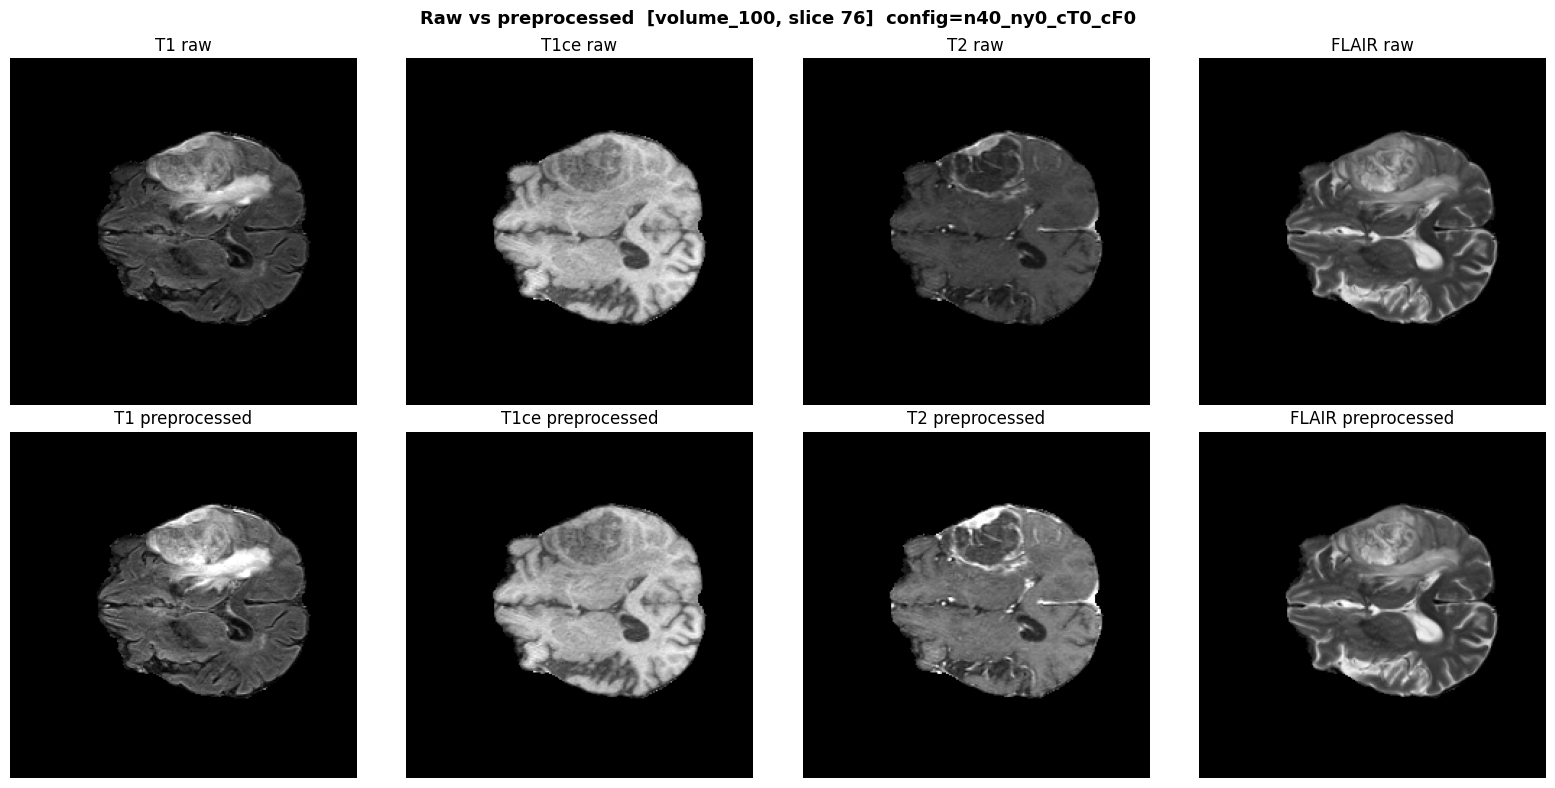

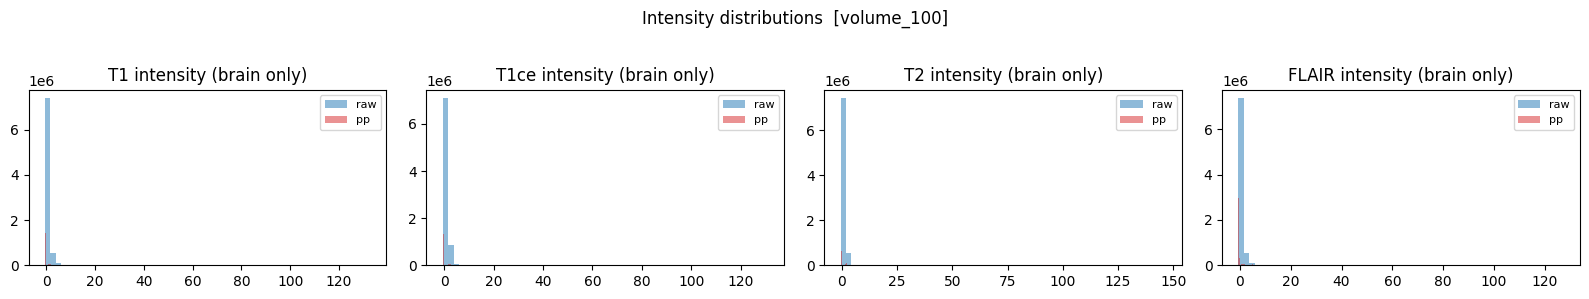

In [7]:
def show_preprocessing_comparison(vid, slice_idx=None):
    img_raw, mask = load_raw_volume(vid, volume_slices[vid])
    img_pp,  _    = load_cached_volume(vid)
    if slice_idx is None:
        tumor_z = [z for z in range(mask.shape[0]) if (mask[z] > 0).any()]
        slice_idx = tumor_z[len(tumor_z) // 2] if tumor_z else mask.shape[0] // 2
    mods = ["T1", "T1ce", "T2", "FLAIR"]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for c in range(4):
        axes[0, c].imshow(img_raw[slice_idx, :, :, c], cmap="gray")
        axes[0, c].set_title(f"{mods[c]} raw"); axes[0, c].axis("off")
        axes[1, c].imshow(img_pp[slice_idx, :, :, c], cmap="gray")
        axes[1, c].set_title(f"{mods[c]} preprocessed"); axes[1, c].axis("off")
    plt.suptitle(f"Raw vs preprocessed  [{vid}, slice {slice_idx}]  "
                  f"config={_prep_config_hash()}", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    brain = (np.abs(img_raw).sum(axis=-1) > 0)
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for c in range(4):
        axes[c].hist(img_raw[..., c][brain].ravel(), bins=60, alpha=0.5,
                      label="raw",  color="C0")
        axes[c].hist(img_pp[..., c][brain].ravel(),  bins=60, alpha=0.5,
                      label="pp",   color="C3")
        axes[c].set_title(f"{mods[c]} intensity (brain only)")
        axes[c].legend(fontsize=8)
    plt.suptitle(f"Intensity distributions  [{vid}]")
    plt.tight_layout(); plt.show()


show_preprocessing_comparison(example_vid)


## Dataset --- patch-based 3D

The dataset wraps the cached preprocessed volumes and produces, on demand,
the (image, multi-channel target) pairs that MONAI's transform pipeline
will then crop into 3D patches.  Each `__getitem__` call:

1. Loads the cached preprocessed `.npz` for one patient volume from
   `./cache_3d_singlestage/<config_hash>/<volume_id>.npz`.
2. (Optional) Computes the 4 ET-specific feature channels on the fly when
   `use_enhancement_channels=True`, growing the input from 4 to 8 channels.
3. Builds a **3-channel binary target tensor** (WT, TC, ET) from the
   single BraTS label map.
4. Returns `{'image': (C, D, H, W), 'label': (3, D, H, W)}`.

### Target construction

The single BraTS label map (with label-ids 1 = NCR, 2 = ED, 4 = ET) is
expanded into three independent binary masks corresponding to the three
nested clinical sub-regions:

| target channel | derivation                          | clinical meaning |
|----------------|-------------------------------------|------------------|
| 0 — WT         | `label > 0`                          | Whole Tumour (any tumour tissue) |
| 1 — TC         | `(label == 1) or (label == 4)`        | Tumour Core (necrosis ∪ enhancing) |
| 2 — ET         | `label == 4`                         | Enhancing Tumour (thesis target) |

The three channels are *not* mutually exclusive — every ET voxel is also
a TC voxel and a WT voxel, by construction.  This is what allows the
network to use independent sigmoid heads instead of a softmax constraint.

### Patch sampling

MONAI's `RandCropByPosNegLabeld` extracts fixed-size 3D patches from each
volume.  Sampling parameters:

| parameter            | value         | role |
|----------------------|---------------|------|
| `spatial_size`       | `(96, 96, 96)` | Patch dimensions in voxels (set by `CFG['patch_size']`) |
| `pos` (positive ratio) | `1.0`        | Fraction of patches centred on a tumour voxel |
| `neg` (negative ratio) | `0.0`        | Fraction of patches centred on a background voxel |
| `num_samples`        | `2`           | Patches drawn per volume per epoch |
| `image_threshold`    | `0.0`         | Minimum image intensity for valid patch centres |

With `pos=1.0, neg=0.0`, **every training patch is guaranteed to contain
tumour tissue at its centre**.  This concentrates gradient on the
informative region of each volume and fixes a known failure mode of pure
random sampling, where the model collapses to "predict background"
because >99 % of randomly-located patches contain no ET voxel at all.

### Why patches and not whole volumes?

A full BraTS volume is `240 × 240 × 155 ≈ 8.9 M` voxels with 4 modalities.
Holding even one such volume in autograd memory through a 3D U-Net of the
size used here exceeds 6 GB.  Patch-based training:

- **Fits memory**: 96³ ≈ 0.88 M voxels — about a tenth of the whole-volume size.
- **Increases effective sample diversity**: each volume contributes multiple
  random patches per epoch, with random crop locations + flips + intensity
  augmentation, so the optimiser sees thousands of distinct inputs even from
  221 training patients.
- **Matches inference**: at test time, sliding-window inference reconstructs
  full-volume predictions from overlapping patches with the *same* 96³
  receptive field the model was trained on, so train and test see
  consistent context.


In [8]:
def build_multiclass_target(label_dhw: np.ndarray) -> np.ndarray:
    """BraTS label-id (0 / 1=NCR / 2=ED / 4=ET) -> (3, D, H, W) binary."""
    wt = (label_dhw > 0).astype(np.float32)
    tc = ((label_dhw == 1) | (label_dhw == 4)).astype(np.float32)
    et = (label_dhw == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=0)


def et_enhancement_channels(img_dhwc: np.ndarray) -> np.ndarray:
    """Build per-slice enhancement / Sobel / LoG channels -> (D, H, W, 4)."""
    t1ce = img_dhwc[..., 1]; t1 = img_dhwc[..., 0]
    D = t1ce.shape[0]
    enh  = np.stack([pp.enhancement_map_alpha(t1ce[d], t1[d], alpha=1.0) for d in range(D)])
    nenh = np.stack([pp.normalized_enhancement(t1ce[d], t1[d])        for d in range(D)])
    sobel= np.stack([pp.sobel_magnitude(t1ce[d])                        for d in range(D)])
    log_ = np.stack([pp.laplacian_of_gaussian(enh[d], sigma=1.5)        for d in range(D)])
    return np.stack([enh, nenh, sobel, log_], axis=-1).astype(np.float32)


class BraTSVolDataset(Dataset):
    """Returns {image: (C, D, H, W), label: (3, D, H, W)} per volume."""
    def __init__(self, volume_ids, transform=None):
        self.vids = sorted(volume_ids)
        self.transform = transform

    def __len__(self):
        return len(self.vids)

    def __getitem__(self, idx):
        vid = self.vids[idx]
        img, lbl = load_cached_volume(vid)                    # (D, H, W, 4), (D, H, W)
        if CFG['use_enhancement_channels']:
            extra = et_enhancement_channels(img)              # (D, H, W, 4)
            img = np.concatenate([img, extra], axis=-1)
        img = np.moveaxis(img, -1, 0).astype(np.float32)      # -> (C, D, H, W)
        tgt = build_multiclass_target(lbl).astype(np.float32) # (3, D, H, W)
        sample = {
            'image': torch.from_numpy(img),
            'label': torch.from_numpy(tgt),
        }
        if self.transform is not None:
            sample = self.transform(sample)
        return sample


# ---- MONAI transforms ----
train_tfm = Compose([
    EnsureTyped(keys=['image', 'label']),
    RandCropByPosNegLabeld(
        keys=['image', 'label'],
        label_key='label',
        spatial_size=CFG['patch_size'],
        pos=CFG['pos_ratio'],
        neg=CFG['neg_ratio'],
        num_samples=CFG['samples_per_volume'],
        image_key='image',
        image_threshold=0.0,
    ),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
    RandScaleIntensityd(keys='image', factors=0.1, prob=0.5),
    RandShiftIntensityd(keys='image', offsets=0.1, prob=0.5),
])
val_tfm = Compose([EnsureTyped(keys=['image', 'label'])])

train_ds = BraTSVolDataset(train_vols, transform=train_tfm)
val_ds   = BraTSVolDataset(val_vols,   transform=val_tfm)
test_ds  = BraTSVolDataset(test_vols,  transform=val_tfm)
print(f'train volumes={len(train_ds)}  val volumes={len(val_ds)}  test volumes={len(test_ds)}')

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], pin_memory=torch.cuda.is_available(),
    collate_fn=list_data_collate,           # MONAI handles list-of-patch flattening
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=torch.cuda.is_available(),
)


train volumes=221  val volumes=73  test volumes=75


## Visualise the ET-specific feature channels

When `use_enhancement_channels=True`, the model sees 4 extra channels per
slice on top of the 4 raw modalities:

| channel | formula | role |
|---------|---------|------|
| Enhancement map (α=1.0)  | `clip(T1ce − T1, 0)`              | Isolates gadolinium uptake — direct ET prior |
| Normalised enhancement   | `(T1ce − T1) / (T1ce + T1 + ε)`   | Scale-invariant ratio, robust across patients |
| Sobel (T1ce)              | `‖∇T1ce‖`                          | Tumour-boundary edge detector |
| LoG of enhancement       | `∇²G_σ ∗ (enhancement map)`        | Ring detector for ET (responds to high-curvature boundaries) |

The visualisation overlays the GT ET contour (lime green) on each channel
so you can verify that bright pixels align with the enhancing ring.  The
function works regardless of whether the channels are actually fed to the
model — they're built on the fly for display.


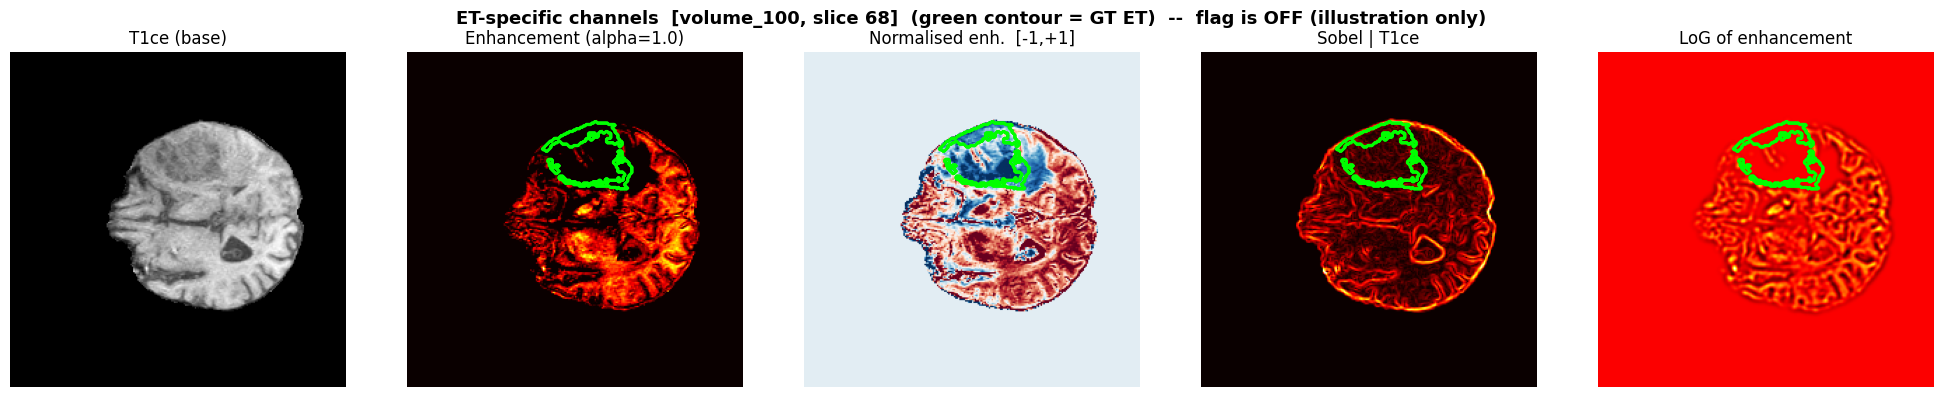

In [9]:
def show_enhancement_channels(vid, slice_idx=None):
    """Visualise the 4 ET-specific channels for illustration.

    Rendering choices:
    - Panels 2 and 5 use the `hot` colormap with the BRAIN MASK out
      (background -> grey) so zero-signal areas don't saturate the cmap.
    - Panel 3 uses a divergent cmap centred at 0 (`RdBu_r`) so its
      [-1, +1] values display with white-at-zero and colour away from 0.
    """
    img_pp, lbl = load_cached_volume(vid)
    extra = et_enhancement_channels(img_pp)          # (D, H, W, 4)
    if slice_idx is None:
        et_z = [z for z in range(lbl.shape[0]) if (lbl[z] == 4).any()]
        slice_idx = et_z[len(et_z) // 2] if et_z else lbl.shape[0] // 2

    t1ce = img_pp[slice_idx, :, :, 1]
    brain = (np.abs(img_pp[slice_idx]).sum(axis=-1) > 0)
    et_mask = (lbl[slice_idx] == 4).astype(float)

    def masked(a, m):
        """Set background to NaN so matplotlib renders it as the bad-color (transparent)."""
        out = np.where(m, a, np.nan)
        return out

    names = ["Enhancement (alpha=1.0)", "Normalised enh.  [-1,+1]",
              "Sobel | T1ce", "LoG of enhancement"]
    cmaps = ["hot", "RdBu_r", "hot", "hot"]
    # Symmetric limits for the divergent panel:
    vmaxes = [None, 0.5, None, None]
    vmins  = [None, -0.5, None, None]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(t1ce, cmap="gray")
    axes[0].set_title("T1ce (base)"); axes[0].axis("off")
    for c in range(4):
        data = masked(extra[slice_idx, :, :, c], brain)
        im = axes[c + 1].imshow(data, cmap=cmaps[c],
                                  vmin=vmins[c], vmax=vmaxes[c])
        if et_mask.sum() > 0:
            axes[c + 1].contour(et_mask, colors="lime", linewidths=1.5)
        axes[c + 1].set_title(names[c]); axes[c + 1].axis("off")

    active = "ON (fed to model)" if CFG.get("use_enhancement_channels", False) else "OFF (illustration only)"
    plt.suptitle(f"ET-specific channels  [{vid}, slice {slice_idx}]  "
                  f"(green contour = GT ET)  --  flag is {active}",
                  fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


# Always render these for the thesis -- the channels are built on the fly so
# the visualisation works regardless of whether the training flag is on.
show_enhancement_channels(example_vid)


## Visualise a training patch

Pulls one *post-augmentation* sample from `train_ds`: the 96³ patch the
network actually sees during training, plus its 3-channel target (WT, TC, ET)
overlaid on T1ce.  Re-run the cell to see a different random crop.


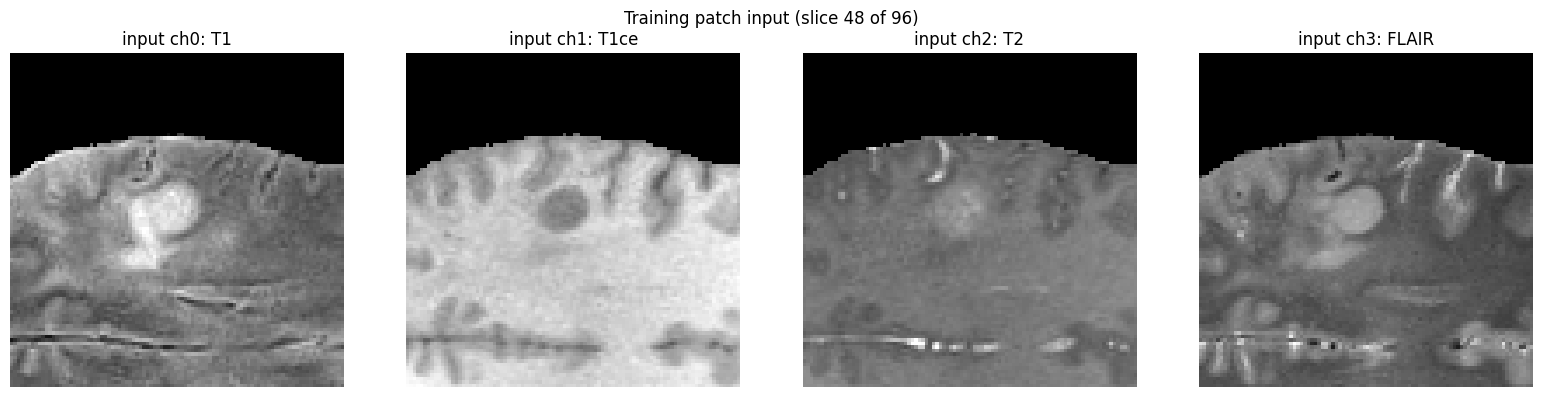

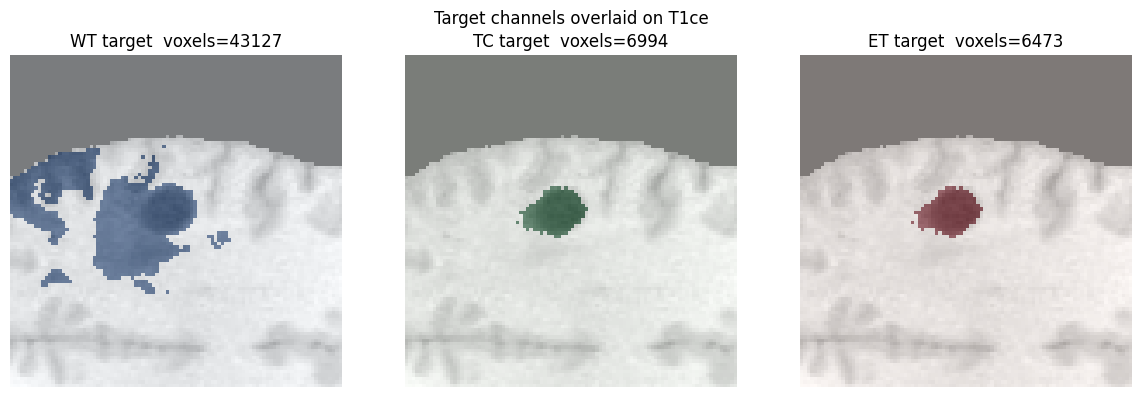

In [10]:
def show_training_patch():
    import torch as _torch
    sample = train_ds[0]
    if isinstance(sample, list):
        sample = sample[0]            # RandCropByPosNegLabeld returns list when num_samples>1
    img = sample["image"]
    lbl = sample["label"]
    if isinstance(img, _torch.Tensor):
        img = img.detach().cpu().numpy()
    if isinstance(lbl, _torch.Tensor):
        lbl = lbl.detach().cpu().numpy()

    tumor_z = [z for z in range(lbl.shape[1]) if lbl[:, z].sum() > 0]
    z = tumor_z[len(tumor_z) // 2] if tumor_z else lbl.shape[1] // 2

    ch_names = ["T1", "T1ce", "T2", "FLAIR", "enh", "normEnh", "Sobel", "LoG"]
    n_show = min(img.shape[0], 4)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for c in range(n_show):
        axes[c].imshow(img[c, z], cmap="gray")
        axes[c].set_title(f"input ch{c}: {ch_names[c]}")
        axes[c].axis("off")
    plt.suptitle(f"Training patch input (slice {z} of {img.shape[1]})")
    plt.tight_layout(); plt.show()

    t1ce = img[1, z]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    colours = ["Blues", "Greens", "Reds"]
    for c, (name, cmap) in enumerate(zip(["WT", "TC", "ET"], colours)):
        axes[c].imshow(t1ce, cmap="gray")
        axes[c].imshow(lbl[c, z], cmap=cmap, alpha=0.5)
        axes[c].set_title(f"{name} target  voxels={int(lbl[c].sum())}")
        axes[c].axis("off")
    plt.suptitle("Target channels overlaid on T1ce")
    plt.tight_layout(); plt.show()


show_training_patch()


## Model, loss, optimiser

### Architecture — 3D U-Net (MONAI)

A single 3D U-Net encoder–decoder produces all three outputs from one shared
trunk.  This is what makes the *conquer* step in divide-and-conquer
work: gradient from each region's loss flows through the same features,
forcing the encoder to learn a representation jointly useful for WT, TC,
and ET.

| component         | value |
|-------------------|-------|
| Spatial dims      | 3 |
| Encoder channels  | `(16, 32, 64, 128, 160)` — 5 resolution levels |
| Strides           | `(2, 2, 2, 2)` — halve spatial size at each downsample |
| Residual units / level | 2 (`num_res_units=2`) |
| Normalisation     | `GroupNorm(num_groups=1)` — LayerNorm-over-features; stable at batch_size=1 (InstanceNorm collapses sparse-class signal at this batch size) |
| Activation        | PReLU (MONAI default) |
| Input channels    | **4** (baseline) or **8** (with `use_enhancement_channels=True`) |
| Output channels   | **3** — one independent sigmoid head per sub-region (WT, TC, ET) |
| Total parameters  | ≈ 1.9 M (printed at runtime by `model_summary`) |

The three output heads are **independent sigmoids**, not a softmax — because
the regions overlap by construction (every ET voxel is also TC and WT).
A softmax would force them to be mutually exclusive, breaking the
containment hierarchy.

### Loss — `WeightedDiceCE`

Per-region Dice + binary cross-entropy with auto-normalised task weights:

```
L_total =  λ_dice · Σ_c  w_c · DiceLoss(p_c, t_c)
        +  λ_ce   · Σ_c  w_c · BCE(p_c, t_c)         where  c ∈ {WT, TC, ET}
                                                            Σ_c w_c = 1
```

- `p_c = σ(logit_c)`, `t_c` is the binary target for region c.
- Dice loss component:  `1 − (2·Σ p·t + s) / (Σ p + Σ t + s)`, summed over batch and spatial dims, with smoothing constant `s=1`.
- BCE component:  pixel-wise binary cross-entropy with logits.
- Weights `(w_WT, w_TC, w_ET)` are set by `CFG['task_weights']` and **normalised inside the class** so they sum to 1.  This keeps the total loss magnitude comparable across configurations and lets the thesis report weights as percentages.
- `λ_dice = λ_ce = 1.0` in CFG — equal contribution from the region-level (Dice) and pixel-level (BCE) terms.

### Optimiser — AdamW + linear warmup → cosine annealing

| component | value |
|-----------|-------|
| Optimiser            | AdamW (decoupled weight-decay) |
| Learning rate (peak) | `1e-4` |
| Weight decay         | `1e-5` |
| Warmup               | LinearLR, `start_factor=1e-2`, 2 epochs |
| Main schedule        | CosineAnnealingLR, 78 epochs, `eta_min=1e-6` |
| Gradient clipping    | max-norm `1.0` (in `train_stageB`) |

Warmup keeps the first updates small while the U-Net's batch-norm-free,
LayerNorm-style features find a stable scale; cosine annealing then
gently lowers the LR through the rest of training.  This is the schedule
nnU-Net's BraTS pipelines use, simplified to the two-stage setup that fits
the 6 GB-GPU training budget.

### Channel summary

| direction | shape (per patch) | meaning |
|-----------|-------------------|---------|
| Input  | `(1, 4 or 8, 96, 96, 96)`  | 4 modalities + (optionally) 4 ET-feature channels |
| Output | `(1, 3, 96, 96, 96)`        | 3 independent sigmoid heads — WT / TC / ET |


In [11]:
def build_model(in_channels: int, out_channels: int = 3) -> nn.Module:
    if CFG['model'] == 'segresnet':
        return SegResNet(
            spatial_dims=3,
            init_filters=CFG['segresnet_init_filters'],
            in_channels=in_channels,
            out_channels=out_channels,
            dropout_prob=CFG['segresnet_dropout'],
            blocks_down=(1, 2, 2, 4),
            blocks_up=(1, 1, 1),
        )
    return MonaiUNet(
        spatial_dims=3,
        in_channels=in_channels,
        out_channels=out_channels,
        channels=CFG['unet_channels'],
        strides=CFG['unet_strides'],
        num_res_units=2,
        norm=('GROUP', {'num_groups': 1}),   # 1 group == LayerNorm-over-features; works for any channel count including 3
    )


def in_channels_for_cfg() -> int:
    return 4 + (4 if CFG['use_enhancement_channels'] else 0)


MODEL = build_model(in_channels=in_channels_for_cfg(), out_channels=3).to(CFG['device'])
print(f"Model: {CFG['model']}  in={in_channels_for_cfg()}  out=3  "
      f"params={sum(p.numel() for p in MODEL.parameters()):,}")

class WeightedDiceCE(nn.Module):
    """Per-channel Dice + BCE with configurable per-region weights.

    Expects 3 output channels in order (WT, TC, ET).  The weights are
    auto-normalised so their sum is 1.0 -- this keeps the total loss
    magnitude comparable to the unweighted baseline (1/3 + 1/3 + 1/3)
    and lets the thesis report weights as percentages.
    """
    def __init__(self, weights=(1.0, 1.0, 1.0),
                  lambda_dice=1.0, lambda_ce=1.0,
                  smooth=1.0):
        super().__init__()
        w = torch.tensor(weights, dtype=torch.float32)
        w = w / w.sum().clamp(min=1e-8)
        self.register_buffer('w', w)
        self.lambda_dice = float(lambda_dice)
        self.lambda_ce   = float(lambda_ce)
        self.smooth      = float(smooth)

    def forward(self, logits, targets):
        # (B, C=3, D, H, W)
        p = torch.sigmoid(logits.float())
        t = targets.float()

        # Per-channel soft Dice loss (sum over batch + spatial, keep channel axis)
        dims = tuple(d for d in range(p.ndim) if d != 1)
        inter = (p * t).sum(dim=dims)
        denom = p.sum(dim=dims) + t.sum(dim=dims)
        dice_per_ch = 1.0 - (2.0 * inter + self.smooth) / (denom + self.smooth)

        # Per-channel BCE
        bce = F.binary_cross_entropy_with_logits(logits, t, reduction='none')
        bce_per_ch = bce.mean(dim=dims)

        w = self.w.to(dice_per_ch.device)
        total = (self.lambda_dice * (dice_per_ch * w).sum()
                  + self.lambda_ce   * (bce_per_ch  * w).sum())
        return total


criterion = WeightedDiceCE(
    weights=CFG['task_weights'],
    lambda_dice=CFG['dice_weight'],
    lambda_ce=CFG['ce_weight'],
).to(CFG['device'])

print(f"Loss: WeightedDiceCE  weights={CFG['task_weights']}  "
      f"(normalised: {[round(x, 3) for x in (criterion.w.tolist())]})")

optimiser = torch.optim.AdamW(MODEL.parameters(),
                               lr=CFG['lr'],
                               weight_decay=CFG['weight_decay'])
_warm = CFG['warmup_epochs']; _tot = CFG['epochs']
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimiser,
    schedulers=[
        torch.optim.lr_scheduler.LinearLR(optimiser, start_factor=1e-2, end_factor=1.0, total_iters=_warm),
        torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max(1, _tot - _warm), eta_min=1e-6),
    ],
    milestones=[_warm],
)


Model: unet  in=4  out=3  params=3,223,616
Loss: WeightedDiceCE  weights=(1.0, 1.0, 1.0)  (normalised: [0.333, 0.333, 0.333])


c:\Users\bhmed\anaconda3\envs\brats\lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


## Model summary

Total parameter count and the 10 heaviest modules — used in the thesis
Methods chapter to characterise the network's capacity.


In [12]:
def model_summary(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model:             {CFG['model']}")
    print(f"Total params:      {total:>12,}")
    print(f"Trainable params:  {train:>12,}")
    print(f"Model size (fp32): {total * 4 / 1e6:.2f} MB")

    rows = []
    for name, mod in model.named_modules():
        if name == "":
            continue
        n = sum(p.numel() for p in mod.parameters(recurse=False))
        if n > 0:
            rows.append((name, n))
    rows.sort(key=lambda r: -r[1])
    print("\nTop 10 heaviest modules:")
    for nm, n in rows[:10]:
        bar = "#" * max(1, int(50 * n / rows[0][1]))
        print(f"  {nm[:40]:<40s} {n:>10,}  {bar}")


model_summary(MODEL)


Model:             unet
Total params:         3,223,616
Trainable params:     3,223,616
Model size (fp32): 12.89 MB

Top 10 heaviest modules:
  model.1.submodule.1.submodule.1.submodul    691,360  ##################################################
  model.1.submodule.1.submodule.1.submodul    553,120  ########################################
  model.1.submodule.1.submodule.1.submodul    497,728  ###################################
  model.1.submodule.1.submodule.1.submodul    442,496  ################################
  model.1.submodule.1.submodule.1.submodul    221,312  ################
  model.1.submodule.1.submodule.1.submodul    221,312  ################
  model.1.submodule.1.submodule.0.conv.uni    110,656  ########
  model.1.submodule.1.submodule.1.submodul    110,656  ########
  model.1.submodule.1.submodule.2.0.conv      110,624  ########
  model.1.submodule.1.submodule.0.conv.uni     55,360  ####


## Training

### Per-epoch loop

For each of `CFG['epochs']` epochs the training step does, in order:

1. **Iterate patches** from `train_loader` (≈ 221 batches × `samples_per_volume`=2 = 442 patches per epoch).
2. **Forward pass in fp32** — full-precision is used because autocast + GroupNorm
   produced NaN gradients at `batch_size=1` in earlier runs; the small patch /
   small model size makes fp32 affordable on a 6 GB GPU.
3. **Loss = `WeightedDiceCE`** (per-region Dice + BCE with `task_weights`).
4. **Three independent NaN guards**:
   - non-finite logits → skip batch,
   - non-finite loss → skip batch,
   - any non-finite gradient → zero grads and skip step.
   These guards prevent a single rogue batch from poisoning the model weights.
5. **Gradient-norm clip** at `max_norm = 1.0`, then `optimiser.step()`.
6. **Scheduler step** (LinearLR warmup → CosineAnnealingLR).
7. **`torch.cuda.empty_cache()`** to reclaim fragmented memory between epochs.

### Validation (every `val_every = 2` epochs)

Validation runs `sliding_window_inference` on **full** validation volumes:

- ROI size = `(96, 96, 96)` (matches training patch size, so train-time receptive field carries over)
- Overlap = 0.5
- Gaussian weighting at window edges (smooths sliding-window seams)

For each volume the per-region Dice is computed at the configured
`et_threshold = 0.5` and averaged over the 73 validation patients to give
`val_WT`, `val_TC`, `val_ET`.  This is the *honest* metric — it mirrors
exactly what the test-set evaluation does, with no patch-cropping
shortcuts.

### Checkpoint selection

The model is saved to `singlestage3d_best.pth` whenever **val ET Dice
improves** (the thesis target).  Each ablation runner additionally copies
this file to a tagged filename (e.g. `singlestage3d_best__weighting_equal.pth`)
once the row finishes, so no later row can overwrite it.

### Resume mechanics

`singlestage3d_last.pth` is overwritten **every epoch** with the full
training state:

- model weights,
- optimiser momentum,
- scheduler step counter,
- best-so-far ET Dice,
- early-stop patience counter,
- per-epoch history (loss, val_WT, val_TC, val_ET),
- preprocessing-config hash (`prep_hash`).

A second call to `train_stageB()` automatically reloads this state and
continues from the next epoch — provided the saved `prep_hash` matches the
current `CFG`.  If the preprocessing config changed between runs, the
guard refuses to resume and starts fresh (resuming a model trained on
different inputs would be incorrect).

### Early stopping

Training breaks if `val ET` does not improve for **15 consecutive
validation checks** (= 30 epochs at `val_every=2`).  The latest
`singlestage3d_last.pth` and the best-so-far `singlestage3d_best.pth`
both remain on disk after early-stop.


In [13]:
@torch.no_grad()
def validate_volumes(model, loader, threshold=0.5):
    model.eval()
    device = CFG['device']
    d_wt, d_tc, d_et = [], [], []
    for batch in loader:
        img = batch['image'].to(device)
        lbl = batch['label'].to(device)
        logits = sliding_window_inference(
            inputs=img,
            roi_size=CFG['sw_roi'],
            sw_batch_size=1,
            predictor=model,
            overlap=CFG['sw_overlap'],
            mode=('gaussian' if CFG['sw_gaussian'] else 'constant'),
        )
        pred = (torch.sigmoid(logits) > threshold).float()
        for c, acc in zip([0, 1, 2], [d_wt, d_tc, d_et]):
            p = pred[0, c]; g = lbl[0, c]
            inter = (p * g).sum(); denom = p.sum() + g.sum()
            acc.append((2 * inter / (denom + 1e-7)).item()
                        if denom > 0 else 1.0)
    return float(np.mean(d_wt)), float(np.mean(d_tc)), float(np.mean(d_et))


def train_stageB(resume=True):
    device = CFG['device']

    # ---- Resume state (if available) ----
    start_epoch = 1
    best_et = -1.0
    patience = 0
    history = []

    last_path = os.path.join(CFG['checkpoint_dir'], 'singlestage3d_last.pth')
    if resume and os.path.exists(last_path):
        try:
            ckpt = torch.load(last_path, map_location=device, weights_only=False)
            ckpt_prep = ckpt.get('prep_hash', None)
            curr_prep = _prep_config_hash()
            if ckpt_prep is not None and ckpt_prep != curr_prep:
                warnings.warn(
                    f'Preprocessing config changed (ckpt={ckpt_prep}, '
                    f'current={curr_prep}). Starting from scratch.')
            else:
                MODEL.load_state_dict(ckpt['model_state_dict'])
                if 'optimiser_state_dict' in ckpt:
                    optimiser.load_state_dict(ckpt['optimiser_state_dict'])
                if 'scheduler_state_dict' in ckpt:
                    try:
                        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
                    except Exception as _e:
                        warnings.warn(f'scheduler state load failed: {_e}')
                start_epoch = ckpt.get('epoch', 0) + 1
                best_et = ckpt.get('best_et', -1.0)
                patience = ckpt.get('patience', 0)
                history = list(ckpt.get('history', []))
                print(f'Resumed from epoch {start_epoch - 1}  '
                      f'best_et={best_et:.4f}  patience={patience}  '
                      f'history_len={len(history)}')
        except Exception as e:
            warnings.warn(f'Resume failed ({e}); starting from scratch.')
            start_epoch, best_et, patience, history = 1, -1.0, 0, []

    if start_epoch > CFG['epochs']:
        print(f'Already trained to epoch {start_epoch - 1} >= '
              f'CFG["epochs"]={CFG["epochs"]}. Raise CFG["epochs"] to continue.')
        return history

    for epoch in range(start_epoch, CFG['epochs'] + 1):
        MODEL.train()
        running = 0.0; n_batches = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{CFG["epochs"]}'):
            img = batch['image'].to(device, non_blocking=True)
            lbl = batch['label'].to(device, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)
            # fp32 forward: SegResNet with GroupNorm on 6GB GPUs
            logits = MODEL(img)
            loss = criterion(logits, lbl)
            if not torch.isfinite(logits).all():
                warnings.warn(f'Non-finite logits at epoch {epoch}; skipping batch.')
                optimiser.zero_grad(set_to_none=True); continue
            if not torch.isfinite(loss):
                warnings.warn(f'Non-finite loss at epoch {epoch}; skipping batch.')
                optimiser.zero_grad(set_to_none=True); continue
            loss.backward()
            grads_ok = all(p.grad is None or torch.isfinite(p.grad).all()
                            for p in MODEL.parameters())
            if not grads_ok:
                optimiser.zero_grad(set_to_none=True); continue
            torch.nn.utils.clip_grad_norm_(MODEL.parameters(), CFG['grad_clip'])
            optimiser.step()
            running += loss.item(); n_batches += 1
        avg_loss = running / max(1, n_batches)
        scheduler.step()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        val_ran = False
        if (epoch % CFG['val_every'] == 0) or (epoch == CFG['epochs']):
            d_wt, d_tc, d_et = validate_volumes(MODEL, val_loader,
                                                  threshold=CFG['et_threshold'])
            history.append((epoch, avg_loss, d_wt, d_tc, d_et))
            val_ran = True
            improved = d_et > best_et
            tag = '  *best*' if improved else f'  (noimp {patience+1}/{CFG["early_stop_patience"]})'
            print(f'Epoch {epoch:3d}  loss={avg_loss:.4f}  WT={d_wt:.4f}  '
                  f'TC={d_tc:.4f}  ET={d_et:.4f}{tag}')
            if improved:
                best_et = d_et; patience = 0
                torch.save({'model_state_dict': MODEL.state_dict(),
                            'epoch': epoch, 'best_et': best_et,
                            'prep_hash': _prep_config_hash()},
                           os.path.join(CFG['checkpoint_dir'], 'singlestage3d_best.pth'))
            else:
                patience += 1

        # Save full state every epoch for true resume
        torch.save({
            'model_state_dict':     MODEL.state_dict(),
            'optimiser_state_dict': optimiser.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch':    epoch,
            'best_et':  best_et,
            'patience': patience,
            'history':  history,
            'prep_hash': _prep_config_hash(),
        }, last_path)

        if val_ran and patience >= CFG['early_stop_patience']:
            print(f'Early stop at epoch {epoch}')
            break

    return history


def load_history_from_last():
    """Return the per-epoch history list from singlestage3d_last.pth, else []."""
    last_path = os.path.join(CFG['checkpoint_dir'], 'singlestage3d_last.pth')
    if not os.path.exists(last_path):
        return []
    ckpt = torch.load(last_path, map_location='cpu', weights_only=False)
    return list(ckpt.get('history', []))


# Start / resume training:
# history = train_stageB()


## Training curves

Plots training loss and per-region validation Dice across epochs.
`plot_training_curves()` with no arguments auto-loads the full history
from `singlestage3d_last.pth`, so it works even after a kernel restart.


In [14]:
def plot_training_curves(hist=None, title_suffix=""):
    if hist is None:
        hist = load_history_from_last()
    if not hist:
        print("No history. Run  history = train_stageB()  first.")
        return
    ep    = [h[0] for h in hist]
    loss  = [h[1] for h in hist]
    d_wt  = [h[2] for h in hist]
    d_tc  = [h[3] for h in hist]
    d_et  = [h[4] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(ep, loss, "b-o", markersize=3)
    ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss")
    ax1.set_title(f"Training loss{title_suffix}"); ax1.grid(alpha=0.3)
    ax2.plot(ep, d_wt, "C0-o", markersize=3, label="WT")
    ax2.plot(ep, d_tc, "C2-o", markersize=3, label="TC")
    ax2.plot(ep, d_et, "C3-o", markersize=3, label="ET  (thesis target)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("val Dice")
    ax2.set_title(f"Per-region validation Dice{title_suffix}")
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
    plt.tight_layout(); plt.show()


# Call with no args -> loads full history from ./checkpoints/singlestage3d_last.pth
# plot_training_curves()


## Test evaluation

Sliding-window inference (96³ ROI, 50 % overlap, Gaussian weighting) on
each of the 75 held-out test volumes; reports per-region Dice for WT, TC,
and ET.  The **ET Dice** is the thesis' top-line metric.


In [15]:
def load_best_singlestage(tag=None):
    """Load a 'best' checkpoint into MODEL.

    tag=None              -> singlestage3d_best.pth (most recent training)
    tag='equal' / 'et_heavy' / ... (weighting tag) ->
                              singlestage3d_best__weighting_<tag>.pth
    tag='baseline' / 'n4' / 'nyul' / 'clahe' / 'enh_channels' / 'full' (preprocessing tag) ->
                              singlestage3d_best__<tag>.pth
    Falls back to whichever exists.
    """
    ck_dir = CFG['checkpoint_dir']
    if tag is None:
        cand = [os.path.join(ck_dir, 'singlestage3d_best.pth')]
    else:
        cand = [
            os.path.join(ck_dir, f'singlestage3d_best__weighting_{tag}.pth'),
            os.path.join(ck_dir, f'singlestage3d_best__{tag}.pth'),
            os.path.join(ck_dir, 'singlestage3d_best.pth'),
        ]
    p = next((c for c in cand if os.path.exists(c)), cand[-1])
    sd = torch.load(p, map_location=CFG['device'], weights_only=False)
    MODEL.load_state_dict(sd['model_state_dict'])
    print(f"Loaded {p}  epoch={sd.get('epoch')}  "
          f"best_et={sd.get('best_et', float('nan')):.4f}  "
          f"prep={sd.get('prep_hash', '?')}")
    return sd


@torch.no_grad()
def evaluate_test(threshold: float = 0.5, return_per_vol: bool = True):
    device = CFG['device']
    MODEL.eval()
    per_vol = []
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                              num_workers=CFG['num_workers'])
    for batch in tqdm(test_loader, desc='Test eval'):
        img = batch['image'].to(device); lbl = batch['label'].to(device)
        logits = sliding_window_inference(
            inputs=img, roi_size=CFG['sw_roi'], sw_batch_size=1,
            predictor=MODEL, overlap=CFG['sw_overlap'],
            mode=('gaussian' if CFG['sw_gaussian'] else 'constant'),
        )
        pred = (torch.sigmoid(logits) > threshold).float()
        dices = []
        for c in range(3):
            p = pred[0, c]; g = lbl[0, c]
            inter = (p * g).sum(); denom = p.sum() + g.sum()
            dices.append((2 * inter / (denom + 1e-7)).item()
                          if denom > 0 else 1.0)
        per_vol.append(dices)
    arr = np.array(per_vol)
    out = {'WT': float(arr[:, 0].mean()),
           'TC': float(arr[:, 1].mean()),
           'ET': float(arr[:, 2].mean())}
    if return_per_vol:
        out['per_volume'] = arr
    return out

# Uncomment after training:
# load_best_singlestage()
# results = evaluate_test(threshold=CFG['et_threshold'])
# print(f"Test  WT={results['WT']:.4f}  TC={results['TC']:.4f}  ET={results['ET']:.4f}")


## Visualise test-set predictions

Qualitative output for a selected test volume: a 3×3 grid showing T1ce,
ground-truth, and model prediction per region (WT / TC / ET).  Per-volume
Dice is reported in each prediction panel's title for direct comparison.


In [16]:
def show_test_prediction(vid, threshold=None, slice_idx=None):
    import torch as _torch
    threshold = threshold if threshold is not None else CFG["et_threshold"]
    img_pp, lbl = load_cached_volume(vid)
    if CFG["use_enhancement_channels"]:
        extra  = et_enhancement_channels(img_pp)
        img_in = np.concatenate([img_pp, extra], axis=-1)
    else:
        img_in = img_pp
    img_c = np.moveaxis(img_in, -1, 0).astype(np.float32)
    inp   = _torch.from_numpy(img_c).unsqueeze(0).to(CFG["device"])
    gt    = build_multiclass_target(lbl)

    MODEL.eval()
    with _torch.no_grad():
        logits = sliding_window_inference(
            inp, CFG["sw_roi"], 1, MODEL,
            overlap=CFG["sw_overlap"],
            mode=("gaussian" if CFG["sw_gaussian"] else "constant"),
        )
    probs = _torch.sigmoid(logits)[0].cpu().numpy()
    pred  = (probs > threshold).astype(np.float32)

    if slice_idx is None:
        et_z = [z for z in range(gt[2].shape[0]) if gt[2, z].sum() > 0]
        slice_idx = et_z[len(et_z) // 2] if et_z else gt.shape[1] // 2

    t1ce_slice = img_pp[slice_idx, :, :, 1]
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for row, (name, idx) in enumerate([("WT", 0), ("TC", 1), ("ET", 2)]):
        axes[row, 0].imshow(t1ce_slice, cmap="gray")
        axes[row, 0].set_title("T1ce"); axes[row, 0].axis("off")
        axes[row, 1].imshow(t1ce_slice, cmap="gray")
        axes[row, 1].imshow(gt[idx, slice_idx], cmap="Greens", alpha=0.55)
        axes[row, 1].set_title(f"{name} GT  ({int(gt[idx].sum())} vox)")
        axes[row, 1].axis("off")
        inter = (pred[idx] * gt[idx]).sum()
        denom = pred[idx].sum() + gt[idx].sum()
        dice  = (2 * inter / (denom + 1e-7)) if denom > 0 else 1.0
        axes[row, 2].imshow(t1ce_slice, cmap="gray")
        axes[row, 2].imshow(pred[idx, slice_idx], cmap="Reds", alpha=0.55)
        axes[row, 2].set_title(f"{name} Pred  vol-Dice={dice:.3f}")
        axes[row, 2].axis("off")
    plt.suptitle(f"{vid}  slice {slice_idx}  threshold={threshold}",
                  fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


# Example usage (uncomment after loading a checkpoint):
# load_best_singlestage()
# show_test_prediction(sorted(test_vols)[0])


## Thesis ablation plan

Each row flips a single CFG flag (or small group) and is an independent
training run.  Cache is automatic per-config.  Record the ET number per row
and report the table in the Results chapter.

| # | variant | flags changed |
|---|---------|---------------|
| 1 | **baseline**       | (z-score only) |
| 2 | + N4               | `use_n4=True` |
| 3 | + Nyul             | `use_nyul=True` |
| 4 | + CLAHE            | `use_clahe_t1ce=True, use_clahe_flair=True` |
| 5 | + enh-channels     | `use_enhancement_channels=True` |
| 6 | full (all above)   | everything on |

Expected: each row improves ET Dice by roughly 0.01-0.03 over the previous,
landing the full run in the 0.78-0.82 range.  Rename
`singlestage3d_best.pth` to `singlestage3d_best__<variant>.pth`
after each run so you keep every checkpoint for the thesis report.


In [17]:
# Template for running an ablation row.  Uncomment the call at the bottom.

ABL_PLAN = [
    ('baseline',      dict()),
    ('n4',            dict(use_n4=True)),
    ('nyul',          dict(use_nyul=True)),
    ('clahe',         dict(use_clahe_t1ce=True, use_clahe_flair=True)),
    ('enh_channels',  dict(use_enhancement_channels=True)),
    ('full',          dict(use_n4=True, use_nyul=True,
                            use_clahe_t1ce=True, use_clahe_flair=True,
                            use_enhancement_channels=True)),
]


def run_ablation_row(row_idx, verbose=True):
    """Run one preprocessing-ablation row end-to-end.

    Locks task_weights to ET-HEAVY (winner of the weighting ablation, 0.2/0.3/0.5)
    so this axis only varies preprocessing.  Same isolation guarantees as
    run_weighting_row (re-seed, full cleanup, tagged-file evaluation).
    """
    global MODEL, criterion, optimiser, scheduler, train_ds, val_ds, test_ds, train_loader, val_loader
    import shutil, random as _rnd

    name, overrides = ABL_PLAN[row_idx]

    if verbose:
        print(f"\n=== Preprocessing ablation row {row_idx + 1}: {name}  overrides={overrides} ===")

    # Lock task_weights to the et_heavy winner from the weighting axis
    CFG['task_weights'] = (0.2, 0.3, 0.5)

    # Apply this row's preprocessing overrides
    CFG.update(overrides)

    # Cache preprocessed volumes for this config (no-op for already-cached configs)
    cache_all_volumes(all_vids)

    # Full file cleanup
    for fname in ('singlestage3d_best.pth', 'singlestage3d_last.pth'):
        f = os.path.join(CFG['checkpoint_dir'], fname)
        if os.path.exists(f):
            os.remove(f)

    # Re-seed for deterministic patch order across rows
    seed = CFG['seed']
    _rnd.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        import monai
        monai.utils.set_determinism(seed)
    except Exception:
        pass

    # Rebuild datasets (input channel count may have changed via use_enhancement_channels)
    train_ds = BraTSVolDataset(train_vols, transform=train_tfm)
    val_ds   = BraTSVolDataset(val_vols,   transform=val_tfm)
    test_ds  = BraTSVolDataset(test_vols,  transform=val_tfm)
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                               num_workers=CFG['num_workers'], pin_memory=torch.cuda.is_available(),
                               collate_fn=list_data_collate)
    val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                               num_workers=CFG['num_workers'], pin_memory=torch.cuda.is_available())

    # Fresh criterion with et_heavy weights
    criterion = WeightedDiceCE(
        weights=CFG['task_weights'],
        lambda_dice=CFG['dice_weight'],
        lambda_ce=CFG['ce_weight'],
    ).to(CFG['device'])

    # Fresh model + optimiser + scheduler
    MODEL = build_model(in_channels=in_channels_for_cfg(),
                         out_channels=3).to(CFG['device'])
    optimiser = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'],
                                    weight_decay=CFG['weight_decay'])
    _warm = CFG['warmup_epochs']; _tot = CFG['epochs']
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimiser,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimiser, start_factor=1e-2, end_factor=1.0, total_iters=_warm),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max(1, _tot - _warm), eta_min=1e-6),
        ],
        milestones=[_warm],
    )

    # Train
    hist = train_stageB(resume=False)

    # Tag the best checkpoint
    src = os.path.join(CFG['checkpoint_dir'], 'singlestage3d_best.pth')
    dst = os.path.join(CFG['checkpoint_dir'], f'singlestage3d_best__{name}.pth')
    if os.path.exists(src):
        shutil.copy(src, dst)
        if verbose:
            print(f'Copied best -> {dst}')

    # Evaluate from the tagged file
    load_best_singlestage(tag=name)
    results = evaluate_test(threshold=CFG['et_threshold'])
    if verbose:
        print(f"[{name}]  Test  WT={results['WT']:.4f}  "
              f"TC={results['TC']:.4f}  ET={results['ET']:.4f}")

    return {'name': name, 'overrides': overrides,
            'history': hist, 'test': results,
            'task_weights': list(CFG['task_weights'])}


def run_preprocessing_table(save_json='preprocessing_ablation_results.json',
                              skip_baseline=True):
    """Run the preprocessing ablation rows under the et_heavy weighting.

    By default skips the 'baseline' row (already done in the weighting
    ablation as the et_heavy run); reuses that JSON's number directly.
    """
    import json as _json
    summary = []

    # Pull baseline et_heavy from the weighting JSON (must be present)
    if skip_baseline:
        try:
            with open('task_weighting_results.json') as f:
                tw = _json.load(f)
            et_heavy = next(r for r in tw if r['name'] == 'et_heavy')
            summary.append({
                'name':         'baseline',
                'overrides':    {},
                'task_weights': et_heavy['weights'],
                'test_WT':      et_heavy['test_WT'],
                'test_TC':      et_heavy['test_TC'],
                'test_ET':      et_heavy['test_ET'],
                'reused_from':  'task_weighting_results.json (et_heavy)',
            })
            print("[reused] baseline = et_heavy run "
                  f"(test ET = {et_heavy['test_ET']:.4f})")
        except (FileNotFoundError, StopIteration):
            print("[warn] baseline reuse failed - will run baseline from scratch.")
            skip_baseline = False

    start_idx = 1 if skip_baseline else 0
    for i in range(start_idx, len(ABL_PLAN)):
        r = run_ablation_row(i)
        summary.append({
            'name':         r['name'],
            'overrides':    r['overrides'],
            'task_weights': r['task_weights'],
            'test_WT':      r['test']['WT'],
            'test_TC':      r['test']['TC'],
            'test_ET':      r['test']['ET'],
        })

    with open(save_json, 'w') as f:
        _json.dump(summary, f, indent=2)
    print(f"\nSaved -> {save_json}")

    print("\n| row             | flags                                | test WT  | test TC  | test ET |")
    print("|-----------------|--------------------------------------|----------|----------|---------|")
    for s in summary:
        ovr = '(none)' if not s['overrides'] else ', '.join(f"{k}=True" for k in s['overrides'])
        print(f"| {s['name']:<15} | {ovr:<36} |  {s['test_WT']:.4f}  |  "
              f"{s['test_TC']:.4f}  |  {s['test_ET']:.4f} |")
    return summary


# Usage:
#   single row:    res     = run_ablation_row(1)        # row 1 = N4
#   full table:    summary = run_preprocessing_table()  # skips baseline
summary = run_preprocessing_table()

print(f'Preprocessing ablation ready: {len(ABL_PLAN)} rows.')
for _name, _ovr in ABL_PLAN:
    print(f'  {_name:<15} {_ovr}')


[reused] baseline = et_heavy run (test ET = 0.7292)

=== Preprocessing ablation row 2: n4  overrides={'use_n4': True} ===


Preprocess [n41_ny0_cT0_cF0]:   0%|          | 0/369 [00:00<?, ?it/s]

Epoch 1/80:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 2/80:   0%|          | 0/221 [00:00<?, ?it/s]

c:\Users\bhmed\anaconda3\envs\brats\lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


...

Epoch 77/80:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 78/80:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch  78  loss=0.2089  WT=0.8049  TC=0.7945  ET=0.6874  (noimp 15/15)
Early stop at epoch 78
Copied best -> ./checkpoints\singlestage3d_best__full.pth
Loaded ./checkpoints\singlestage3d_best__full.pth  epoch=48  best_et=0.7009  prep=n41_ny1_cT1_cF1


Test eval:   0%|          | 0/75 [00:00<?, ?it/s]

[full]  Test  WT=0.8568  TC=0.8158  ET=0.7331

Saved -> preprocessing_ablation_results.json

| row             | flags                                | test WT  | test TC  | test ET |
|-----------------|--------------------------------------|----------|----------|---------|
| baseline        | (none)                               |  0.8207  |  0.8123  |  0.7292 |
| n4              | use_n4=True                          |  0.8104  |  0.8082  |  0.7254 |
| nyul            | use_nyul=True                        |  0.8097  |  0.8118  |  0.7285 |
| clahe           | use_clahe_t1ce=True, use_clahe_flair=True |  0.8256  |  0.8258  |  0.7341 |
| enh_channels    | use_enhancement_channels=True        |  0.8082  |  0.8170  |  0.7296 |
| full            | use_n4=True, use_nyul=True, use_clahe_t1ce=True, use_clahe_flair=True, use_enhancement_channels=True |  0.8568  |  0.8158  |  0.7331 |
Preprocessing ablation ready: 6 rows.
  baseline        {}
  n4              {'use_n4': True}
  nyul          

## Task-weighting ablation (second axis)

In addition to the preprocessing ablation above, we vary the per-region loss weights
(WT, TC, ET) in the joint loss.  This tests the senior ML claim that *how* divide-and-conquer
is balanced matters as much as *what* features feed it.

| # | scheme       | (w_WT, w_TC, w_ET) | hypothesis |
|---|--------------|--------------------|------------|
| 1 | equal        | (0.33, 0.33, 0.33) | Baseline; symmetric multi-task. |
| 2 | et_heavy     | (0.20, 0.30, 0.50) | Directly emphasises the thesis target. |
| 3 | wt_anchored  | (0.50, 0.30, 0.20) | Easy-task (WT) gradient anchors the encoder. |
| 4 | et_only      | (0.00, 0.00, 1.00) | Removes multi-task benefit — ablation to prove it helps. |

Each row is a fresh training run.  Best checkpoint per row is saved as
`singlestage3d_best__weighting_<name>.pth`.

In [18]:
# ---- 4 task-weighting configurations ----
TASK_WEIGHTS_PLAN = [
    ('equal',       (1.0, 1.0, 1.0)),
    ('et_heavy',    (0.2, 0.3, 0.5)),
    ('wt_anchored', (0.5, 0.3, 0.2)),
    ('et_only',     (0.0, 0.0, 1.0)),
]


def run_weighting_row(row_idx, verbose=True):
    """Run one weighting configuration end-to-end (train + test eval).

    Strict isolation: re-seeds all RNGs from CFG['seed'], removes BOTH
    generic best.pth and last.pth, and evaluates from the row's
    tagged checkpoint (not the generic name).
    """
    global MODEL, criterion, optimiser, scheduler
    import shutil, random as _rnd

    name, weights = TASK_WEIGHTS_PLAN[row_idx]
    CFG['task_weights'] = weights

    if verbose:
        print(f"\n=== Weighting row {row_idx + 1}: {name}   weights={weights} ===")

    # 1) Full file cleanup
    for fname in ('singlestage3d_best.pth', 'singlestage3d_last.pth'):
        f = os.path.join(CFG['checkpoint_dir'], fname)
        if os.path.exists(f):
            os.remove(f)

    # 2) Re-seed all RNGs so each row sees identical random crops
    seed = CFG['seed']
    _rnd.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        import monai
        monai.utils.set_determinism(seed)
    except Exception:
        pass

    # 3) Fresh criterion with new weights
    criterion = WeightedDiceCE(
        weights=CFG['task_weights'],
        lambda_dice=CFG['dice_weight'],
        lambda_ce=CFG['ce_weight'],
    ).to(CFG['device'])

    # 4) Fresh model + optimiser + scheduler
    MODEL = build_model(in_channels=in_channels_for_cfg(),
                         out_channels=3).to(CFG['device'])
    optimiser = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'],
                                    weight_decay=CFG['weight_decay'])
    _warm = CFG['warmup_epochs']; _tot = CFG['epochs']
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimiser,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimiser, start_factor=1e-2, end_factor=1.0, total_iters=_warm),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max(1, _tot - _warm), eta_min=1e-6),
        ],
        milestones=[_warm],
    )

    # 5) Train
    hist = train_stageB(resume=False)

    # 6) Tag the best checkpoint permanently
    src = os.path.join(CFG['checkpoint_dir'], 'singlestage3d_best.pth')
    dst = os.path.join(CFG['checkpoint_dir'],
                        f'singlestage3d_best__weighting_{name}.pth')
    if os.path.exists(src):
        shutil.copy(src, dst)
        if verbose:
            print(f'Copied best -> {dst}')

    # 7) Evaluate from the TAGGED file
    load_best_singlestage(tag=name)
    results = evaluate_test(threshold=CFG['et_threshold'])
    if verbose:
        print(f"[{name}]  Test  WT={results['WT']:.4f}  "
              f"TC={results['TC']:.4f}  ET={results['ET']:.4f}")

    return {'name': name, 'weights': weights,
            'history': hist, 'test': results}


def run_all_weighting_rows(save_json='task_weighting_results.json'):
    """Run all 4 rows and dump a compact JSON summary for the thesis table."""
    import json as _json
    summary = []
    for i in range(len(TASK_WEIGHTS_PLAN)):
        r = run_weighting_row(i)
        summary.append({
            'name':    r['name'],
            'weights': list(r['weights']),
            'test_WT': r['test']['WT'],
            'test_TC': r['test']['TC'],
            'test_ET': r['test']['ET'],
        })
    with open(save_json, 'w') as f:
        _json.dump(summary, f, indent=2)
    print(f"\nSaved summary -> {save_json}")

    # Pretty print as a table
    print("\n| scheme        | (WT, TC, ET)      |  test WT  |  test TC  |  test ET  |")
    print("|---------------|-------------------|-----------|-----------|-----------|")
    for s in summary:
        ws = '(' + ', '.join(f'{x:.2f}' for x in s['weights']) + ')'
        print(f"| {s['name']:<13} | {ws:<17} |  {s['test_WT']:.4f}   |  "
              f"{s['test_TC']:.4f}   |  {s['test_ET']:.4f}   |")
    return summary


# Usage:
#   single row:   res = run_weighting_row(0)        # equal (current baseline)
#   full table:   summary = run_all_weighting_rows()  # ~12 h at ~3 h per row

# print(f"Task-weighting ablation ready: {len(TASK_WEIGHTS_PLAN)} configurations.")
# for name, w in TASK_WEIGHTS_PLAN:
#     print(f"  {name:<13} weights={w}")
